Epoch 1 | Error = 2
Epoch 2 | Error = 3
Epoch 3 | Error = 3
Epoch 4 | Error = 0
Epoch 5 | Error = 0
Epoch 6 | Error = 0
Epoch 7 | Error = 0
Epoch 8 | Error = 0
Epoch 9 | Error = 0
Epoch 10 | Error = 0

Final Weights : [0.2 0.1]
Final Bias : -0.20000000000000004

Predictions:

Input : [0 0] --> Predicted : 0
Input : [0 1] --> Predicted : 0
Input : [1 0] --> Predicted : 0
Input : [1 1] --> Predicted : 1


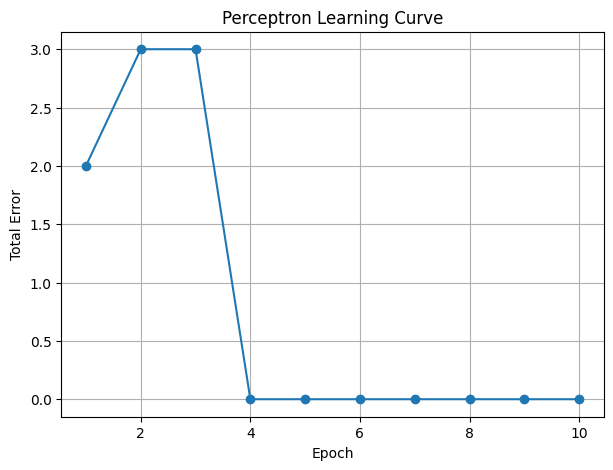

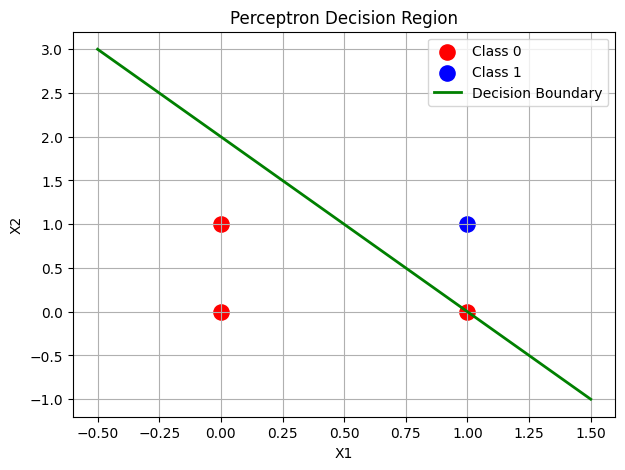

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Input Dataset (AND Gate)
# ----------------------------------------

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Target Output
y = np.array([0, 0, 0, 1])

# ----------------------------------------
# Initialize Parameters
# ----------------------------------------

weights = np.zeros(2)

bias = 0

learning_rate = 0.1

epochs = 10

# Store error for plotting
errors = []

# ----------------------------------------
# Step Activation Function
# ----------------------------------------

def step_function(x):

    return 1 if x >= 0 else 0

# ----------------------------------------
# Perceptron Training
# ----------------------------------------

for epoch in range(epochs):

    total_error = 0

    for i in range(len(X)):

        # Linear Combination
        linear_output = np.dot(
            X[i],
            weights
        ) + bias

        # Predicted Output
        y_pred = step_function(
            linear_output
        )

        # Error Calculation
        error = y[i] - y_pred

        total_error += abs(error)

        # Weight Update Rule
        weights += (
            learning_rate
            * error
            * X[i]
        )

        # Bias Update
        bias += (
            learning_rate
            * error
        )

    # Store epoch error
    errors.append(total_error)

    print(
        f"Epoch {epoch+1} | Error = {total_error}"
    )

# ----------------------------------------
# Final Parameters
# ----------------------------------------

print("\nFinal Weights :", weights)

print("Final Bias :", bias)

# ----------------------------------------
# Predictions
# ----------------------------------------

print("\nPredictions:\n")

for i in range(len(X)):

    linear_output = np.dot(
        X[i],
        weights
    ) + bias

    prediction = step_function(
        linear_output
    )

    print(
        f"Input : {X[i]} --> Predicted : {prediction}"
    )

# ----------------------------------------
# Plot Error Reduction
# ----------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, epochs+1),
    errors,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Total Error")

plt.title("Perceptron Learning Curve")

plt.grid()

plt.show()

# ----------------------------------------
# Plot Decision Region
# ----------------------------------------

plt.figure(figsize=(7,5))

# Plot Data Points
for i in range(len(X)):

    if y[i] == 0:

        plt.scatter(
            X[i][0],
            X[i][1],
            color='red',
            s=120,
            label='Class 0'
            if i == 0 else ""
        )

    else:

        plt.scatter(
            X[i][0],
            X[i][1],
            color='blue',
            s=120,
            label='Class 1'
        )

# Decision Boundary
x_vals = np.linspace(
    -0.5,
    1.5,
    100
)

if weights[1] != 0:

    y_vals = -(
        weights[0] * x_vals + bias
    ) / weights[1]

    plt.plot(
        x_vals,
        y_vals,
        color='green',
        linewidth=2,
        label='Decision Boundary'
    )

plt.xlabel("X1")

plt.ylabel("X2")

plt.title("Perceptron Decision Region")

plt.legend()

plt.grid()

plt.show()